In [10]:
# importing libaries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [13]:
# loading the dataset

ds = load_breast_cancer()

x ,y = ds.data , ds.target



In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [16]:
# decession tree as base

base = DecisionTreeClassifier(max_depth=1, random_state=42)


In [27]:
# AdaBoost classifier
adaboost = AdaBoostClassifier(estimator=base,n_estimators=100,learning_rate=0.5,algorithm="SAMME",random_state=42
)

In [28]:
adaboost.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=100, random_state=42)

In [29]:
y_pre = adaboost.predict(X_test)


In [33]:
# to find the accuracy of the model trainning data

print("Accuracy on training set:", accuracy_score(y_train, adaboost.predict(X_train)))



Accuracy on training set: 1.0


In [30]:
# to find the accuracy of the model tesst data

accuracy = accuracy_score(y_test, y_pre)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.96


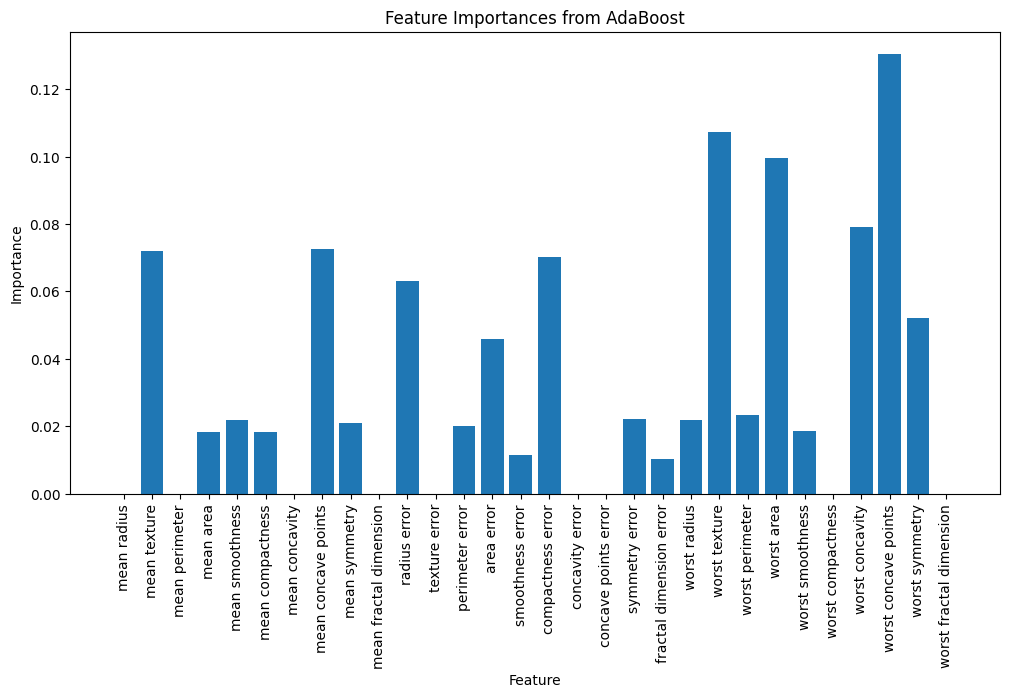

In [35]:
# important feature
plt.figure(figsize=(12,6))
plt.bar(range(x.shape[1]), adaboost.feature_importances_)
plt.xticks(range(x.shape[1]), ds.feature_names, rotation=90)
plt.title("Feature Importances from AdaBoost")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

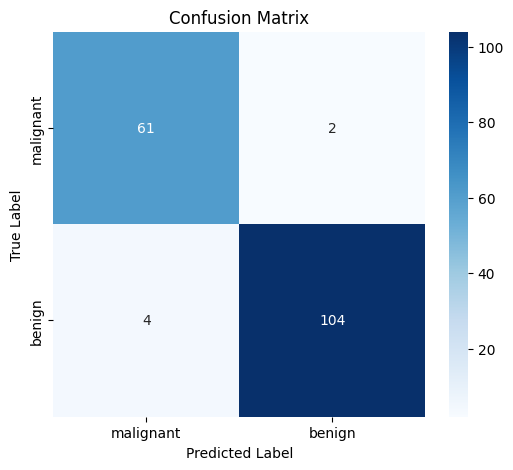

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pre)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ds.target_names,
            yticklabels=ds.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

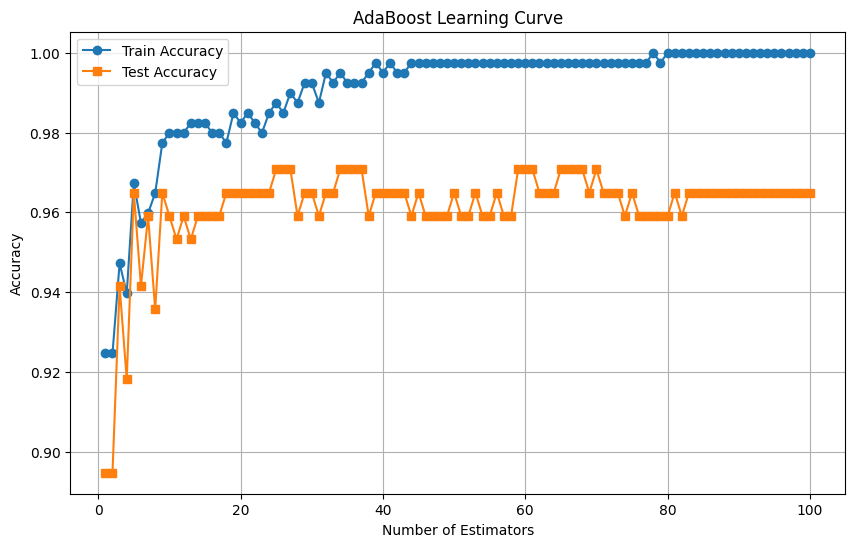

In [38]:
# Learning Curve
train_scores, test_scores = [], []
est_range = range(1, 101)

for n in est_range:
    cur = AdaBoostClassifier(
        estimator=base,
        n_estimators=n,
        learning_rate=0.5,
        random_state=42
    )
    cur.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, cur.predict(X_train)))
    test_scores.append(accuracy_score(y_test, cur.predict(X_test)))

plt.figure(figsize=(10,6))
plt.plot(est_range, train_scores, label="Train Accuracy", marker="o")
plt.plot(est_range, test_scores, label="Test Accuracy", marker="s")
plt.title("AdaBoost Learning Curve")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

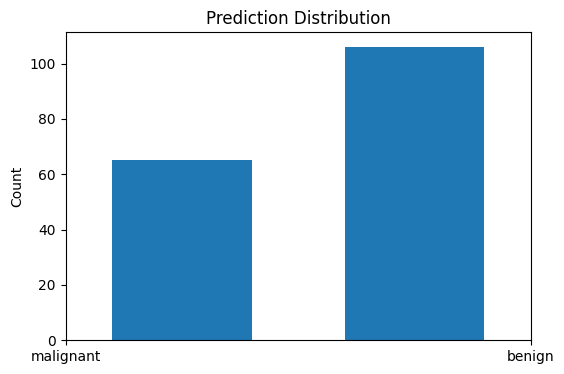

In [41]:
# Prediction Distribution
plt.figure(figsize=(6,4))
plt.hist(y_pre, bins=2, rwidth=0.6)
plt.xticks([0,1], ds.target_names)
plt.title("Prediction Distribution")
plt.ylabel("Count")
plt.show()

In [42]:
# Predictive System
print("\n--- Predictive System Example ---")

sample = X_test[5].reshape(1, -1)
true_label = y_test[5]

prediction = adaboost.predict(sample)[0]
prediction_proba = adaboost.predict_proba(sample)[0]

print("Input Features:", sample)
print("True Label:", ds.target_names[true_label])
print("Predicted Label:", ds.target_names[prediction])
print("Prediction Probabilities:", dict(zip(ds.target_names, prediction_proba)))


--- Predictive System Example ---
Input Features: [[2.060e+01 2.933e+01 1.401e+02 1.265e+03 1.178e-01 2.770e-01 3.514e-01
  1.520e-01 2.397e-01 7.016e-02 7.260e-01 1.595e+00 5.772e+00 8.622e+01
  6.522e-03 6.158e-02 7.117e-02 1.664e-02 2.324e-02 6.185e-03 2.574e+01
  3.942e+01 1.846e+02 1.821e+03 1.650e-01 8.681e-01 9.387e-01 2.650e-01
  4.087e-01 1.240e-01]]
True Label: malignant
Predicted Label: malignant
Prediction Probabilities: {np.str_('malignant'): np.float64(0.810084981988757), np.str_('benign'): np.float64(0.18991501801124308)}
